In [ ]:
!unzip thyroid_ai_project.zip

Archive:  thyroid_ai_project.zip.zip
error [thyroid_ai_project.zip.zip]:  missing 83886080 bytes in zipfile
  (attempting to process anyway)
error: invalid zip file with overlapped components (possible zip bomb)


In [ ]:
!unzip thyroid_ai_project.zip

Archive:  thyroid_ai_project.zip.zip
error [thyroid_ai_project.zip.zip]:  missing 83886080 bytes in zipfile
  (attempting to process anyway)
error: invalid zip file with overlapped components (possible zip bomb)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
base_path = "/content/drive/MyDrive/thyroid_ai_project/dataset/tn3k"

train_img_path = base_path + "/trainval-image"
train_mask_path = base_path + "/trainval-mask"

test_img_path = base_path + "/test-image"
test_mask_path = base_path + "/test-mask"

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
train_images = os.listdir(train_img_path)
test_images = os.listdir(test_img_path)

print("Train images:", len(train_images))
print("Test images:", len(test_images))
print("Total images:", len(train_images) + len(test_images))

Train images: 2879
Test images: 614
Total images: 3493


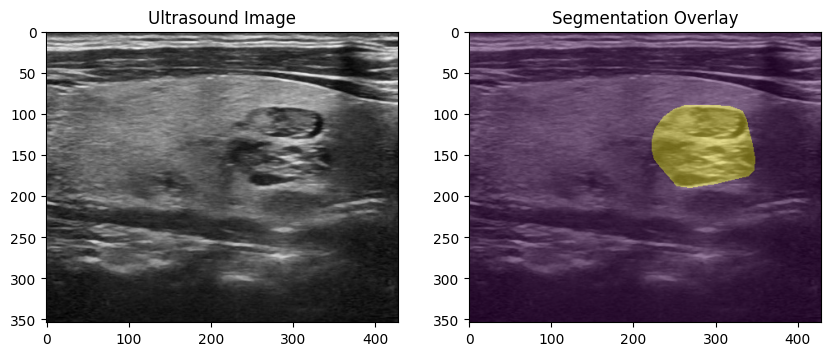

In [8]:
image_name = train_images[0]

image_path = os.path.join(train_img_path, image_name)
mask_path = os.path.join(train_mask_path, image_name)

img = Image.open(image_path)
mask = Image.open(mask_path)

img_array = np.array(img)
mask_array = np.array(mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Ultrasound Image")

plt.subplot(1,2,2)
plt.imshow(img_array, cmap="gray")
plt.imshow(mask_array, alpha=0.4)
plt.title("Segmentation Overlay")

plt.show()

In [9]:
data = []

for img_name in train_images:

    mask_path = os.path.join(train_mask_path, img_name)

    mask = Image.open(mask_path)
    mask_array = np.array(mask)

    pixel_foreground = np.sum(mask_array > 0)
    total_pixel = mask_array.shape[0] * mask_array.shape[1]

    patient_id = img_name.split("_")[0]
    image_id = img_name

    data.append([patient_id, image_id, pixel_foreground, total_pixel])

df = pd.DataFrame(data, columns=[
    "patient_id",
    "image_id",
    "pixel_foreground",
    "total_pixel"
])

df.head()

,patient_id,image_id,pixel_foreground,total_pixel
0,1769.jpg,1769.jpg,11649,151866
1,1723.jpg,1723.jpg,21601,115920
2,1815.jpg,1815.jpg,32754,94053
3,1879.jpg,1879.jpg,60819,158678
4,1836.jpg,1836.jpg,1916,144768


In [10]:
df.to_csv("/content/drive/MyDrive/dataset_statistics.csv", index=False)